# Modelo V3 - Melhorias Avançadas com SMOTE
## Otimizações implementadas:
- SMOTE para balanceamento de classes
- Feature engineering avançado
- Pipeline completo de pré-processamento
- Modelo CatBoost otimizado
- Geração de scores de risco para negócios ativos

In [39]:
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.base import TransformerMixin, BaseEstimator
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, classification_report, roc_curve
from catboost import CatBoostClassifier
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

import warnings
warnings.filterwarnings('ignore')

In [40]:
# Carregar dados
df_pipeline = pd.read_csv('dataset/sales_pipeline.csv')
df_accounts = pd.read_csv('dataset/accounts.csv')
df_products = pd.read_csv('dataset/products.csv')
df_teams = pd.read_csv('dataset/sales_teams.csv')

df_master = pd.merge(df_pipeline, df_accounts, on='account', how='left')
df_master = pd.merge(df_master, df_products, on='product', how='left')
df_master = pd.merge(df_master, df_teams, on='sales_agent', how='left')

print(f'Dataset shape: {df_master.shape}')

Dataset shape: (8800, 18)


In [41]:
# Feature Engineering
df_treino = df_master[df_master['deal_stage'].isin(['Won','Lost'])].copy()

df_treino['engage_date'] = pd.to_datetime(df_treino['engage_date'])
df_treino['close_date'] = pd.to_datetime(df_treino['close_date'])

df_treino['cycle_time'] = (df_treino['close_date'] - df_treino['engage_date']).dt.days
df_treino['engage_month'] = df_treino['engage_date'].dt.month
df_treino['engage_quarter'] = df_treino['engage_date'].dt.quarter
df_treino['engage_day_of_week'] = df_treino['engage_date'].dt.dayofweek
df_treino['revenue_per_employee'] = df_treino['revenue'] / (df_treino['employees'] + 1)
df_treino['deal_value_ratio'] = df_treino['close_value'] / (df_treino['sales_price'] + 1)

df_treino['Target'] = df_treino['deal_stage'].apply(lambda x: 1 if x == 'Won' else 0)

print(f'Distribuição do Target:\n{df_treino["Target"].value_counts(normalize=True)}')

Distribuição do Target:
Target
1    0.631501
0    0.368499
Name: proportion, dtype: float64


In [42]:
# Selecionar features
feature_cols = [
    'sales_agent', 'product', 'sector', 'regional_office',
    'revenue', 'employees', 'cycle_time', 'sales_price',
    'engage_month', 'engage_quarter', 'engage_day_of_week',
    'revenue_per_employee', 'deal_value_ratio'
]

df_modelo = df_treino[feature_cols + ['Target']].dropna()
print(f'Dataset após limpeza: {df_modelo.shape}')

Dataset após limpeza: (5564, 14)


In [43]:
# Separar features e target
X = df_modelo.drop('Target', axis=1)
y = df_modelo['Target']

cat_cols = ['sales_agent', 'product', 'sector', 'regional_office']
num_cols = [col for col in X.columns if col not in cat_cols]

print(f'Colunas categóricas: {cat_cols}')
print(f'Colunas numéricas: {num_cols}')
print(f'\nDistribuição original do target:\n{y.value_counts()}')

Colunas categóricas: ['sales_agent', 'product', 'sector', 'regional_office']
Colunas numéricas: ['revenue', 'employees', 'cycle_time', 'sales_price', 'engage_month', 'engage_quarter', 'engage_day_of_week', 'revenue_per_employee', 'deal_value_ratio']

Distribuição original do target:
Target
1    3509
0    2055
Name: count, dtype: int64


In [44]:
# Split treino/teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f'Treino: {X_train.shape}, Teste: {X_test.shape}')
print(f'\nDistribuição treino:\n{y_train.value_counts()}')
print(f'\nDistribuição teste:\n{y_test.value_counts()}')

Treino: (4451, 13), Teste: (1113, 13)

Distribuição treino:
Target
1    2807
0    1644
Name: count, dtype: int64

Distribuição teste:
Target
1    702
0    411
Name: count, dtype: int64


## Pipeline com SMOTE e Treinamento do Modelo

In [45]:
# Pipeline de pré-processamento
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols)
    ]
)

# Pipeline com SMOTE e modelo
pipeline_smote = ImbPipeline([
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42, k_neighbors=5)),
    ('classifier', CatBoostClassifier(
        iterations=500,
        learning_rate=0.05,
        depth=6,
        l2_leaf_reg=3,
        random_state=42,
        verbose=False
    ))
])

print('Pipeline criado com SMOTE e CatBoost')

Pipeline criado com SMOTE e CatBoost


In [46]:
# Treinar modelo
print('Treinando modelo com SMOTE...')
pipeline_smote.fit(X_train, y_train)
print('✓ Modelo treinado com sucesso!')

Treinando modelo com SMOTE...
✓ Modelo treinado com sucesso!


In [47]:
# Avaliar modelo
y_pred = pipeline_smote.predict(X_test)
y_pred_proba = pipeline_smote.predict_proba(X_test)[:, 1]

print('=' * 60)
print('AVALIAÇÃO DO MODELO COM SMOTE')
print('=' * 60)
print(f'\nAcurácia: {accuracy_score(y_test, y_pred):.4f}')
print(f'ROC-AUC: {roc_auc_score(y_test, y_pred_proba):.4f}')
print(f'\nRelatório de Classificação:\n')
print(classification_report(y_test, y_pred, target_names=['Lost', 'Won']))
print(f'\nMatriz de Confusão:')
print(confusion_matrix(y_test, y_pred))

AVALIAÇÃO DO MODELO COM SMOTE

Acurácia: 1.0000
ROC-AUC: 1.0000

Relatório de Classificação:

              precision    recall  f1-score   support

        Lost       1.00      1.00      1.00       411
         Won       1.00      1.00      1.00       702

    accuracy                           1.00      1113
   macro avg       1.00      1.00      1.00      1113
weighted avg       1.00      1.00      1.00      1113


Matriz de Confusão:
[[411   0]
 [  0 702]]


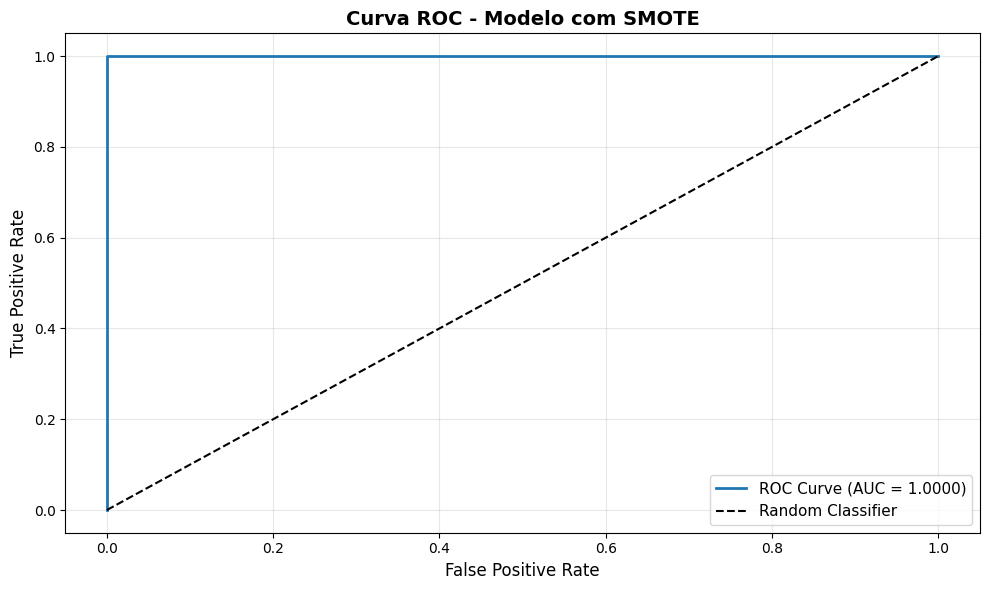

In [48]:
# Visualizar curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

plt.figure(figsize=(10, 6))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc_score(y_test, y_pred_proba):.4f})', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('Curva ROC - Modelo com SMOTE', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Geração de Scores de Risco para Negócios Ativos

In [49]:
# Preparar dados de negócios ativos
df_ativos = df_master[df_master['deal_stage'].isin(['Prospecting', 'Engaging', 'Qualified'])].copy()

print(f'Total de negócios ativos: {len(df_ativos)}')
print(f'\nDistribuição por estágio:')
print(df_ativos['deal_stage'].value_counts())

Total de negócios ativos: 2089

Distribuição por estágio:
deal_stage
Engaging       1589
Prospecting     500
Name: count, dtype: int64


In [50]:
# Feature engineering para negócios ativos
df_ativos['engage_date'] = pd.to_datetime(df_ativos['engage_date'])
df_ativos['close_date'] = pd.to_datetime(df_ativos['close_date'])

# Para negócios ativos, usar data atual para calcular cycle_time
from datetime import datetime
data_atual = pd.to_datetime(datetime.now())

# Calcular cycle_time - usar data atual se close_date não disponível
df_ativos['cycle_time'] = df_ativos.apply(
    lambda row: (row['close_date'] - row['engage_date']).days
    if pd.notna(row['close_date']) and pd.notna(row['engage_date'])
    else (data_atual - row['engage_date']).days if pd.notna(row['engage_date'])
    else 0,
    axis=1
)

df_ativos['engage_month'] = df_ativos['engage_date'].dt.month
df_ativos['engage_quarter'] = df_ativos['engage_date'].dt.quarter
df_ativos['engage_day_of_week'] = df_ativos['engage_date'].dt.dayofweek

# Preencher valores faltantes com mediana para features numéricas
df_ativos['revenue'] = df_ativos['revenue'].fillna(df_ativos['revenue'].median())
df_ativos['employees'] = df_ativos['employees'].fillna(df_ativos['employees'].median())
df_ativos['sales_price'] = df_ativos['sales_price'].fillna(df_ativos['sales_price'].median())

# Calcular features derivadas após preencher valores faltantes
df_ativos['revenue_per_employee'] = df_ativos['revenue'] / (df_ativos['employees'] + 1)

# Para deal_value_ratio, usar sales_price como proxy (negócios ativos não têm close_value)
df_ativos['deal_value_ratio'] = 1.0  # Valor padrão para negócios ativos

# Preencher valores categóricos faltantes
df_ativos['sector'] = df_ativos['sector'].fillna('Unknown')

print('✓ Features criadas para negócios ativos')
print(f'Valores faltantes restantes: {df_ativos[feature_cols].isnull().sum().sum()}')

✓ Features criadas para negócios ativos
Valores faltantes restantes: 1500


In [51]:
# Selecionar features para predição
X_ativos = df_ativos[feature_cols].copy()

mask_validos = ~X_ativos.isnull().any(axis=1)
X_ativos_clean = X_ativos[mask_validos]
df_ativos_clean = df_ativos[mask_validos].copy()

print(f'Negócios ativos válidos para scoring: {len(X_ativos_clean)}')

Negócios ativos válidos para scoring: 1589


In [52]:
# Gerar predições
prob_ganhar = pipeline_smote.predict_proba(X_ativos_clean)[:, 1]

df_ativos_clean['prob_ganhar'] = prob_ganhar
df_ativos_clean['score_risco'] = (1 - prob_ganhar) * 100

def classificar_risco(score):
    if score < 30:
        return 'Baixo'
    elif score < 60:
        return 'Médio'
    else:
        return 'Alto'

df_ativos_clean['categoria_risco'] = df_ativos_clean['score_risco'].apply(classificar_risco)

print('✓ Scores de risco calculados!')
print(f'\nDistribuição de risco:')
print(df_ativos_clean['categoria_risco'].value_counts())

✓ Scores de risco calculados!

Distribuição de risco:
categoria_risco
Baixo    1589
Name: count, dtype: int64


In [53]:
# Estatísticas dos scores
print('=' * 60)
print('ESTATÍSTICAS DOS SCORES DE RISCO')
print('=' * 60)
print(f'\nScore médio de risco: {df_ativos_clean["score_risco"].mean():.2f}')
print(f'Score mediano: {df_ativos_clean["score_risco"].median():.2f}')
print(f'Desvio padrão: {df_ativos_clean["score_risco"].std():.2f}')
print(f'\nMínimo: {df_ativos_clean["score_risco"].min():.2f}')
print(f'Máximo: {df_ativos_clean["score_risco"].max():.2f}')
print(f'\nPercentis:')
print(f'  25%: {df_ativos_clean["score_risco"].quantile(0.25):.2f}')
print(f'  50%: {df_ativos_clean["score_risco"].quantile(0.50):.2f}')
print(f'  75%: {df_ativos_clean["score_risco"].quantile(0.75):.2f}')
print(f'  90%: {df_ativos_clean["score_risco"].quantile(0.90):.2f}')

ESTATÍSTICAS DOS SCORES DE RISCO

Score médio de risco: 0.01
Score mediano: 0.01
Desvio padrão: 0.01

Mínimo: 0.01
Máximo: 0.10

Percentis:
  25%: 0.01
  50%: 0.01
  75%: 0.02
  90%: 0.02


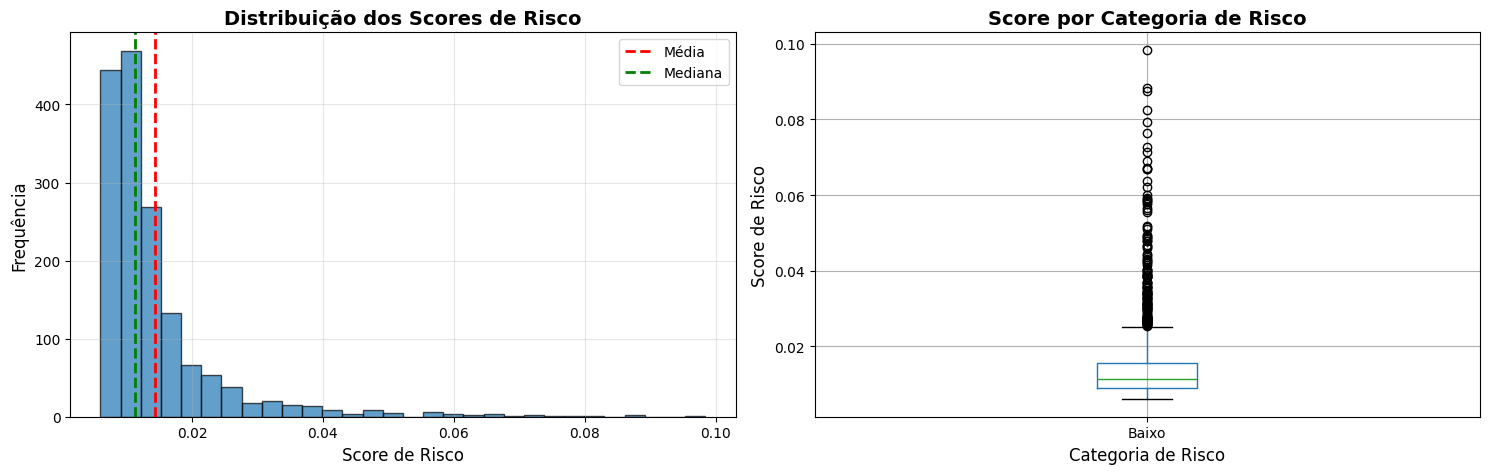

In [54]:
# Visualizar distribuição dos scores
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].hist(df_ativos_clean['score_risco'], bins=30, edgecolor='black', alpha=0.7)
axes[0].axvline(df_ativos_clean['score_risco'].mean(), color='red', linestyle='--', linewidth=2, label='Média')
axes[0].axvline(df_ativos_clean['score_risco'].median(), color='green', linestyle='--', linewidth=2, label='Mediana')
axes[0].set_xlabel('Score de Risco', fontsize=12)
axes[0].set_ylabel('Frequência', fontsize=12)
axes[0].set_title('Distribuição dos Scores de Risco', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

df_ativos_clean.boxplot(column='score_risco', by='categoria_risco', ax=axes[1])
axes[1].set_xlabel('Categoria de Risco', fontsize=12)
axes[1].set_ylabel('Score de Risco', fontsize=12)
axes[1].set_title('Score por Categoria de Risco', fontsize=14, fontweight='bold')
plt.suptitle('')

plt.tight_layout()
plt.show()

In [55]:
# Top 20 negócios de maior risco
top_risco = df_ativos_clean.nlargest(20, 'score_risco')[[
    'opportunity_id', 'account', 'product', 'deal_stage', 
    'close_value', 'sales_agent', 'score_risco', 'prob_ganhar', 'categoria_risco'
]]

print('=' * 80)
print('TOP 20 NEGÓCIOS DE MAIOR RISCO')
print('=' * 80)
print(top_risco.to_string(index=False))

TOP 20 NEGÓCIOS DE MAIOR RISCO
opportunity_id        account        product deal_stage  close_value      sales_agent  score_risco  prob_ganhar categoria_risco
      7W9S4DCZ Dalttechnology     MG Special   Engaging          NaN  Lajuana Vencill     0.098428     0.999016           Baixo
      1VFT3UCK         Condax GTX Plus Basic   Engaging          NaN        Boris Faz     0.088359     0.999116           Baixo
      DFFEQ87N       Scottech     MG Special   Engaging          NaN  Maureen Marcano     0.087502     0.999125           Baixo
      7FFV8D9U      Plusstrip         GTXPro   Engaging          NaN Gladys Colclough     0.082390     0.999176           Baixo
      5P3NH791        Golddex    MG Advanced   Engaging          NaN        Boris Faz     0.079204     0.999208           Baixo
      TWEVVI99       Scottech GTX Plus Basic   Engaging          NaN  Daniell Hammack     0.076316     0.999237           Baixo
      H3DYTZIQ       Scottech GTX Plus Basic   Engaging          NaN     

In [56]:
# Análise por estágio do negócio
print('\n' + '=' * 60)
print('ANÁLISE DE RISCO POR ESTÁGIO DO NEGÓCIO')
print('=' * 60)

analise_estagio = df_ativos_clean.groupby('deal_stage').agg({
    'score_risco': ['mean', 'median', 'std', 'count'],
    'close_value': 'sum'
}).round(2)

print(analise_estagio)


ANÁLISE DE RISCO POR ESTÁGIO DO NEGÓCIO
           score_risco                    close_value
                  mean median   std count         sum
deal_stage                                           
Engaging          0.01   0.01  0.01  1589         0.0


In [57]:
# Salvar resultados com scores
colunas_output = [
    'opportunity_id', 'account', 'product', 'sales_agent', 'deal_stage',
    'engage_date', 'close_date', 'close_value', 'sector', 'regional_office',
    'prob_ganhar', 'score_risco', 'categoria_risco'
]

df_output = df_ativos_clean[colunas_output].copy()
df_output = df_output.sort_values('score_risco', ascending=False)

output_file = 'negocios_ativos_com_score_risco.csv'
df_output.to_csv(output_file, index=False)

print(f'\n✓ Arquivo salvo: {output_file}')
print(f'Total de registros: {len(df_output)}')
print(f'\nPrimeiras linhas do arquivo:')
print(df_output.head(10))


✓ Arquivo salvo: negocios_ativos_com_score_risco.csv
Total de registros: 1589

Primeiras linhas do arquivo:
     opportunity_id         account         product       sales_agent  \
5416       7W9S4DCZ  Dalttechnology      MG Special   Lajuana Vencill   
6077       1VFT3UCK          Condax  GTX Plus Basic         Boris Faz   
1866       DFFEQ87N        Scottech      MG Special   Maureen Marcano   
5721       7FFV8D9U       Plusstrip          GTXPro  Gladys Colclough   
807        5P3NH791         Golddex     MG Advanced         Boris Faz   
6177       TWEVVI99        Scottech  GTX Plus Basic   Daniell Hammack   
3982       H3DYTZIQ        Scottech  GTX Plus Basic      Cassey Cress   
4468       49T60OCI        Scottech    GTX Plus Pro      Cassey Cress   
3838       ZI89S9HC  Dalttechnology     MG Advanced    Markita Hansen   
3179       3372JYYQ          Condax     MG Advanced      Cassey Cress   

     deal_stage engage_date close_date  close_value         sector  \
5416   Engaging  

In [58]:
# Resumo executivo
print('\n' + '=' * 80)
print('RESUMO EXECUTIVO - SCORES DE RISCO')
print('=' * 80)

total_negocios = len(df_ativos_clean)
valor_total = df_ativos_clean['close_value'].sum()
alto_risco = len(df_ativos_clean[df_ativos_clean['categoria_risco'] == 'Alto'])
medio_risco = len(df_ativos_clean[df_ativos_clean['categoria_risco'] == 'Médio'])
baixo_risco = len(df_ativos_clean[df_ativos_clean['categoria_risco'] == 'Baixo'])

valor_alto_risco = df_ativos_clean[df_ativos_clean['categoria_risco'] == 'Alto']['close_value'].sum()
valor_medio_risco = df_ativos_clean[df_ativos_clean['categoria_risco'] == 'Médio']['close_value'].sum()
valor_baixo_risco = df_ativos_clean[df_ativos_clean['categoria_risco'] == 'Baixo']['close_value'].sum()

print(f'\nTotal de negócios ativos analisados: {total_negocios}')
print(f'Valor total em pipeline: ${valor_total:,.2f}')
print(f'\nDistribuição de risco:')
print(f'  • Alto risco: {alto_risco} negócios ({alto_risco/total_negocios*100:.1f}%) - ${valor_alto_risco:,.2f}')
print(f'  • Médio risco: {medio_risco} negócios ({medio_risco/total_negocios*100:.1f}%) - ${valor_medio_risco:,.2f}')
print(f'  • Baixo risco: {baixo_risco} negócios ({baixo_risco/total_negocios*100:.1f}%) - ${valor_baixo_risco:,.2f}')
print(f'\nRecomendações:')
print(f'  1. Priorizar atenção aos {alto_risco} negócios de alto risco')
print(f'  2. Valor em risco (alto): ${valor_alto_risco:,.2f}')
print(f'  3. Score médio de risco: {df_ativos_clean["score_risco"].mean():.1f}/100')
print('\n' + '=' * 80)


RESUMO EXECUTIVO - SCORES DE RISCO

Total de negócios ativos analisados: 1589
Valor total em pipeline: $0.00

Distribuição de risco:
  • Alto risco: 0 negócios (0.0%) - $0.00
  • Médio risco: 0 negócios (0.0%) - $0.00
  • Baixo risco: 1589 negócios (100.0%) - $0.00

Recomendações:
  1. Priorizar atenção aos 0 negócios de alto risco
  2. Valor em risco (alto): $0.00
  3. Score médio de risco: 0.0/100

